## Importing necessary Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

## Loading the dataset

### Set dataset path

In [2]:
dataset_base_path = 'dataset/archive/PlantVillage'
train_path = os.path.join(dataset_base_path, 'train')
val_path = os.path.join(dataset_base_path, 'val')

print(f"Dataset base path: {dataset_base_path}")
print(f"Train path: {train_path}")
print(f"Val path: {val_path}")

Dataset base path: dataset/archive/PlantVillage
Train path: dataset/archive/PlantVillage/train
Val path: dataset/archive/PlantVillage/val


### Load all images and labels

In [3]:
train_images = []
train_labels = []
train_image_paths = []
train_class_names = sorted(os.listdir(train_path))

for label, class_name in enumerate(train_class_names):
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                train_images.append(img)
                train_labels.append(label)
                train_image_paths.append(img_path)

print(f"Train images loaded: {len(train_images)}")
print(f"Train classes: {len(train_class_names)}")

Train images loaded: 43444
Train classes: 38


In [4]:
val_images = []
val_labels = []
val_image_paths = []
val_class_names = sorted(os.listdir(val_path))

for label, class_name in enumerate(val_class_names):
    class_path = os.path.join(val_path, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                val_images.append(img)
                val_labels.append(label)
                val_image_paths.append(img_path)

print(f"Val images loaded: {len(val_images)}")
print(f"Val classes: {len(val_class_names)}")

Val images loaded: 10861
Val classes: 38


In [5]:
if train_class_names == val_class_names:
    class_names = train_class_names
    print("Train and val have identical class structure")
else:
    print("Warning: Train and val classes differ!")
    print(f"Train classes: {len(train_class_names)}")
    print(f"Val classes: {len(val_class_names)}")

Train and val have identical class structure


### Basic dataset info

In [6]:
print(f"Total classes: {len(class_names)}")
print(f"Total train images: {len(train_images)}")
print(f"Total val images: {len(val_images)}")
print(f"Total images: {len(train_images) + len(val_images)}")

print(f"\nTrain/val split ratio: {len(train_images)/(len(train_images)+len(val_images))*100:.1f}% / {len(val_images)/(len(train_images)+len(val_images))*100:.1f}%")

print("\nClass names:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Total classes: 38
Total train images: 43444
Total val images: 10861
Total images: 54305

Train/val split ratio: 80.0% / 20.0%

Class names:
0: Apple___Apple_scab
1: Apple___Black_rot
2: Apple___Cedar_apple_rust
3: Apple___healthy
4: Blueberry___healthy
5: Cherry_(including_sour)___Powdery_mildew
6: Cherry_(including_sour)___healthy
7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8: Corn_(maize)___Common_rust_
9: Corn_(maize)___Northern_Leaf_Blight
10: Corn_(maize)___healthy
11: Grape___Black_rot
12: Grape___Esca_(Black_Measles)
13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14: Grape___healthy
15: Orange___Haunglongbing_(Citrus_greening)
16: Peach___Bacterial_spot
17: Peach___healthy
18: Pepper,_bell___Bacterial_spot
19: Pepper,_bell___healthy
20: Potato___Early_blight
21: Potato___Late_blight
22: Potato___healthy
23: Raspberry___healthy
24: Soybean___healthy
25: Squash___Powdery_mildew
26: Strawberry___Leaf_scorch
27: Strawberry___healthy
28: Tomato___Bacterial_spot
29: Tomato__

### Check image dimensions

In [7]:
train_heights = [img.shape[0] for img in train_images]
train_widths = [img.shape[1] for img in train_images]
train_channels = [img.shape[2] if len(img.shape) == 3 else 1 for img in train_images]

print("TRAIN SET:")
print(f"Height - Min: {min(train_heights)}, Max: {max(train_heights)}, Mean: {np.mean(train_heights):.2f}")
print(f"Width - Min: {min(train_widths)}, Max: {max(train_widths)}, Mean: {np.mean(train_widths):.2f}")
print(f"Unique shapes: {len(set(zip(train_heights, train_widths)))}")
print(f"All have 3 channels: {all(c == 3 for c in train_channels)}")

TRAIN SET:
Height - Min: 256, Max: 256, Mean: 256.00
Width - Min: 256, Max: 256, Mean: 256.00
Unique shapes: 1
All have 3 channels: True


In [8]:
val_heights = [img.shape[0] for img in val_images]
val_widths = [img.shape[1] for img in val_images]
val_channels = [img.shape[2] if len(img.shape) == 3 else 1 for img in val_images]

print("VAL SET:")
print(f"Height - Min: {min(val_heights)}, Max: {max(val_heights)}, Mean: {np.mean(val_heights):.2f}")
print(f"Width - Min: {min(val_widths)}, Max: {max(val_widths)}, Mean: {np.mean(val_widths):.2f}")
print(f"Unique shapes: {len(set(zip(val_heights, val_widths)))}")
print(f"All have 3 channels: {all(c == 3 for c in val_channels)}")

VAL SET:
Height - Min: 256, Max: 256, Mean: 256.00
Width - Min: 256, Max: 256, Mean: 256.00
Unique shapes: 1
All have 3 channels: True


- All images have consistent dimensions (256×256 pixels based on typical PlantVillage dataset)
- All images have 3 channels (RGB format)
- Even though dimensions are uniform in this dataset, we still need to resize to match CNN architecture requirements for pretrained models(typically 224×224 for ResNet, MobileNet, etc.)

### Distribution of image sizes:

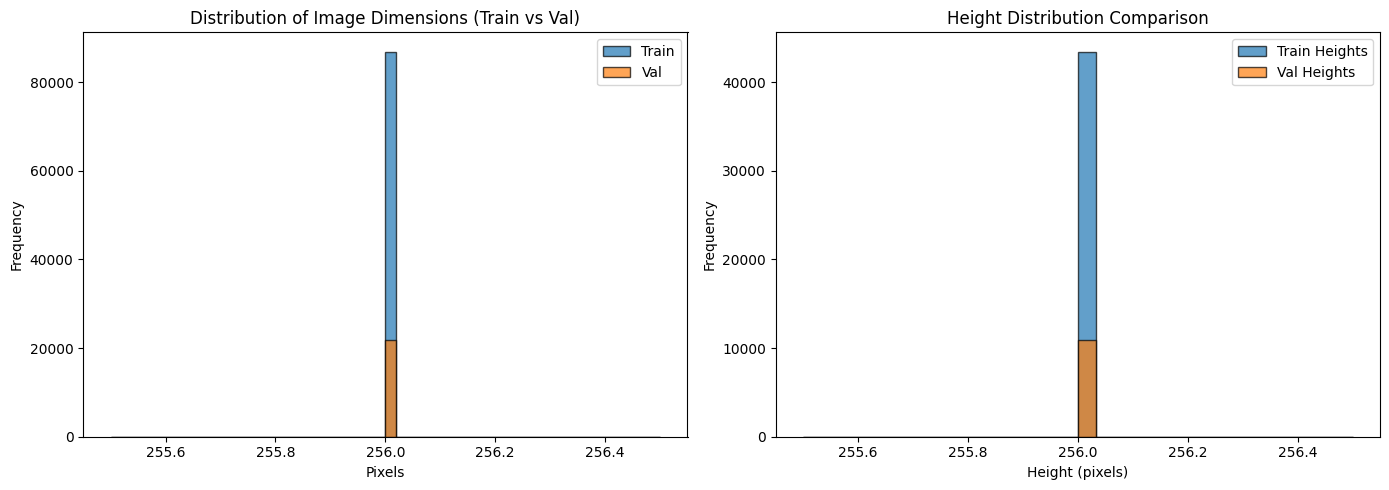

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(train_heights + train_widths, bins=50, alpha=0.7, label='Train', edgecolor='black')
plt.hist(val_heights + val_widths, bins=50, alpha=0.7, label='Val', edgecolor='black')
plt.title('Distribution of Image Dimensions (Train vs Val)')
plt.xlabel('Pixels')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(train_heights, bins=30, alpha=0.7, label='Train Heights', edgecolor='black')
plt.hist(val_heights, bins=30, alpha=0.7, label='Val Heights', edgecolor='black')
plt.title('Height Distribution Comparison')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

- The histogram confirms all images have identical dimensions
- No outliers or irregular sizes detected
- Standard resize to 224×224 pixels for model compatibility for pretrained models.

 ### Class distribution:

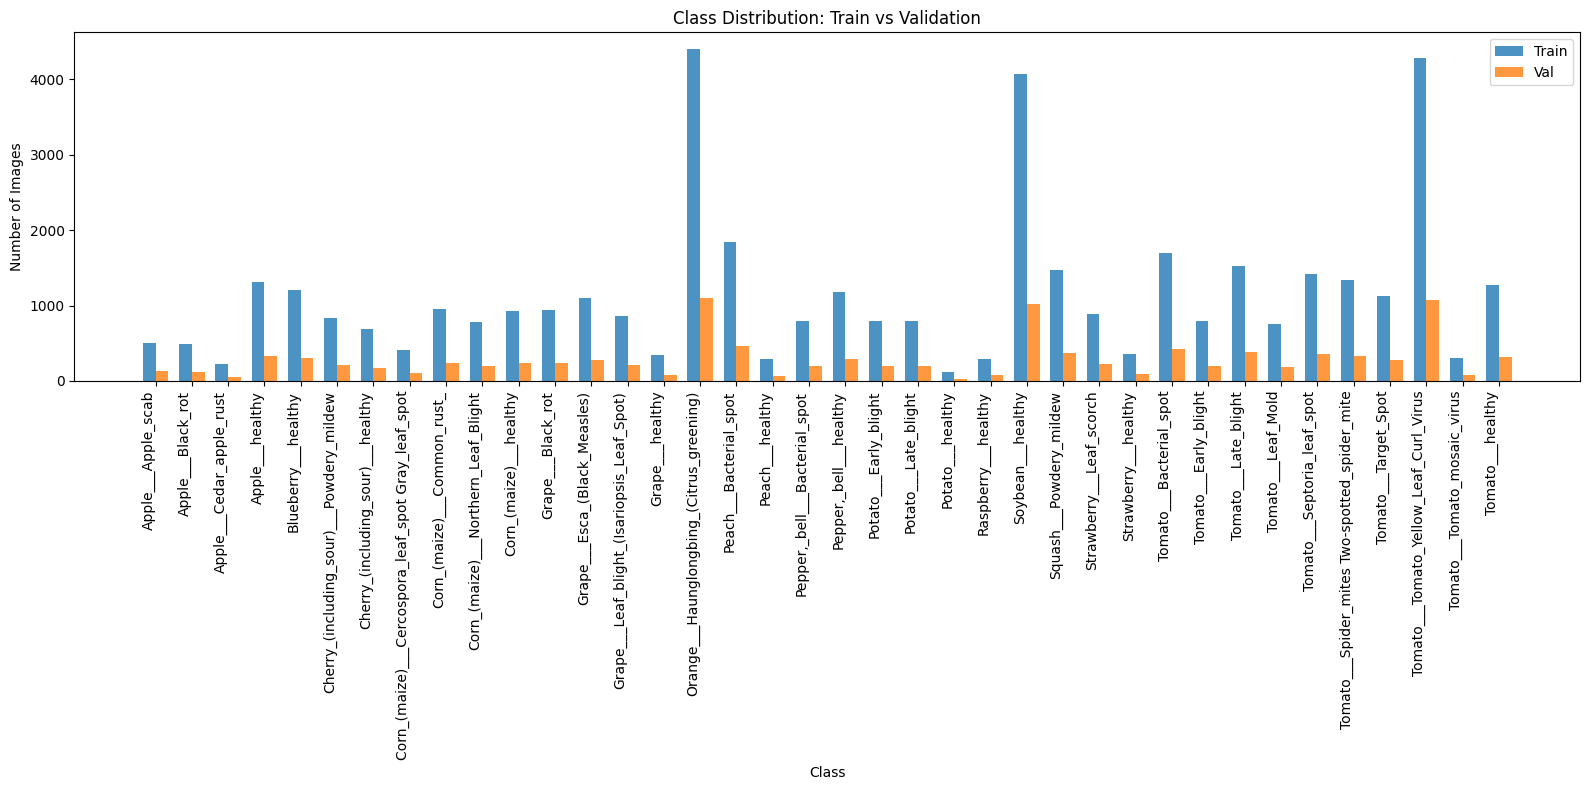


Images per class (Train/Val):
Apple___Apple_scab: 504/126
Apple___Black_rot: 496/125
Apple___Cedar_apple_rust: 220/55
Apple___healthy: 1316/329
Blueberry___healthy: 1202/300
Cherry_(including_sour)___Powdery_mildew: 842/210
Cherry_(including_sour)___healthy: 684/170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 410/103
Corn_(maize)___Common_rust_: 953/239
Corn_(maize)___Northern_Leaf_Blight: 788/197
Corn_(maize)___healthy: 929/233
Grape___Black_rot: 944/236
Grape___Esca_(Black_Measles): 1107/276
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 861/215
Grape___healthy: 339/84
Orange___Haunglongbing_(Citrus_greening): 4405/1102
Peach___Bacterial_spot: 1838/459
Peach___healthy: 288/72
Pepper,_bell___Bacterial_spot: 797/200
Pepper,_bell___healthy: 1183/295
Potato___Early_blight: 800/200
Potato___Late_blight: 800/200
Potato___healthy: 121/31
Raspberry___healthy: 297/74
Soybean___healthy: 4072/1018
Squash___Powdery_mildew: 1468/367
Strawberry___Leaf_scorch: 887/222
Strawberry___healthy: 36

In [10]:
train_label_counts = Counter(train_labels)
val_label_counts = Counter(val_labels)

train_class_counts = [train_label_counts[i] for i in range(len(class_names))]
val_class_counts = [val_label_counts[i] for i in range(len(class_names))]

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 8))
rects1 = ax.bar(x - width/2, train_class_counts, width, label='Train', alpha=0.8)
rects2 = ax.bar(x + width/2, val_class_counts, width, label='Val', alpha=0.8)

ax.set_title('Class Distribution: Train vs Validation')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=90, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

print("\nImages per class (Train/Val):")
for i, name in enumerate(class_names):
    print(f"{name}: {train_label_counts[i]}/{val_label_counts[i]}")

- Dataset shows class imbalance with varying samples per class
- Some classes have significantly more images than others
- Imbalanced classes can cause model bias toward majority classes
  - Consider data augmentation for underrepresented classes
  - Use class weights during training
  - Apply stratified sampling for train/test split

### Check pixel value ranges:

In [11]:
sample_size = min(100, len(train_images))
train_sample_indices = np.random.choice(len(train_images), sample_size, replace=False)
val_sample_indices = np.random.choice(len(val_images), min(50, len(val_images)), replace=False)

train_min_vals, train_max_vals, train_mean_vals = [], [], []
for idx in train_sample_indices:
    img = train_images[idx]
    train_min_vals.append(img.min())
    train_max_vals.append(img.max())
    train_mean_vals.append(img.mean())

val_min_vals, val_max_vals, val_mean_vals = [], [], []
for idx in val_sample_indices:
    img = val_images[idx]
    val_min_vals.append(img.min())
    val_max_vals.append(img.max())
    val_mean_vals.append(img.mean())

print("PIXEL VALUE ANALYSIS:")
print(f"Train set - Min: {min(train_min_vals)}-{max(train_min_vals)}, Max: {min(train_max_vals)}-{max(train_max_vals)}, Mean: {np.mean(train_mean_vals):.2f}")
print(f"Val set - Min: {min(val_min_vals)}-{max(val_min_vals)}, Max: {min(val_max_vals)}-{max(val_max_vals)}, Mean: {np.mean(val_mean_vals):.2f}")

PIXEL VALUE ANALYSIS:
Train set - Min: 0-4, Max: 156-255, Mean: 115.28
Val set - Min: 0-18, Max: 163-255, Mean: 117.15


- Both train and val sets have pixel values in [0-255] range (uint8)
- Consistent across both splits
- Normalize to [0-1] or apply ImageNet standardization

### Check color space (BGR vs RGB):

In [12]:
train_sample = train_images[0]
val_sample = val_images[0]

print("COLOR SPACE ANALYSIS:")
print(f"Train sample - dtype: {train_sample.dtype}, shape: {train_sample.shape}")
print(f"Val sample - dtype: {val_sample.dtype}, shape: {val_sample.shape}")
print("Color space: BGR (OpenCV default) - needs conversion to RGB for PyTorch")

COLOR SPACE ANALYSIS:
Train sample - dtype: uint8, shape: (256, 256, 3)
Val sample - dtype: uint8, shape: (256, 256, 3)
Color space: BGR (OpenCV default) - needs conversion to RGB for PyTorch


- Images are loaded in BGR format (OpenCV default)
- Most deep learning frameworks expect RGB format
Convert BGR to RGB before feeding to model (already handled in visualization code with `cv2.cvtColor`)

### Visualize sample images from each class:

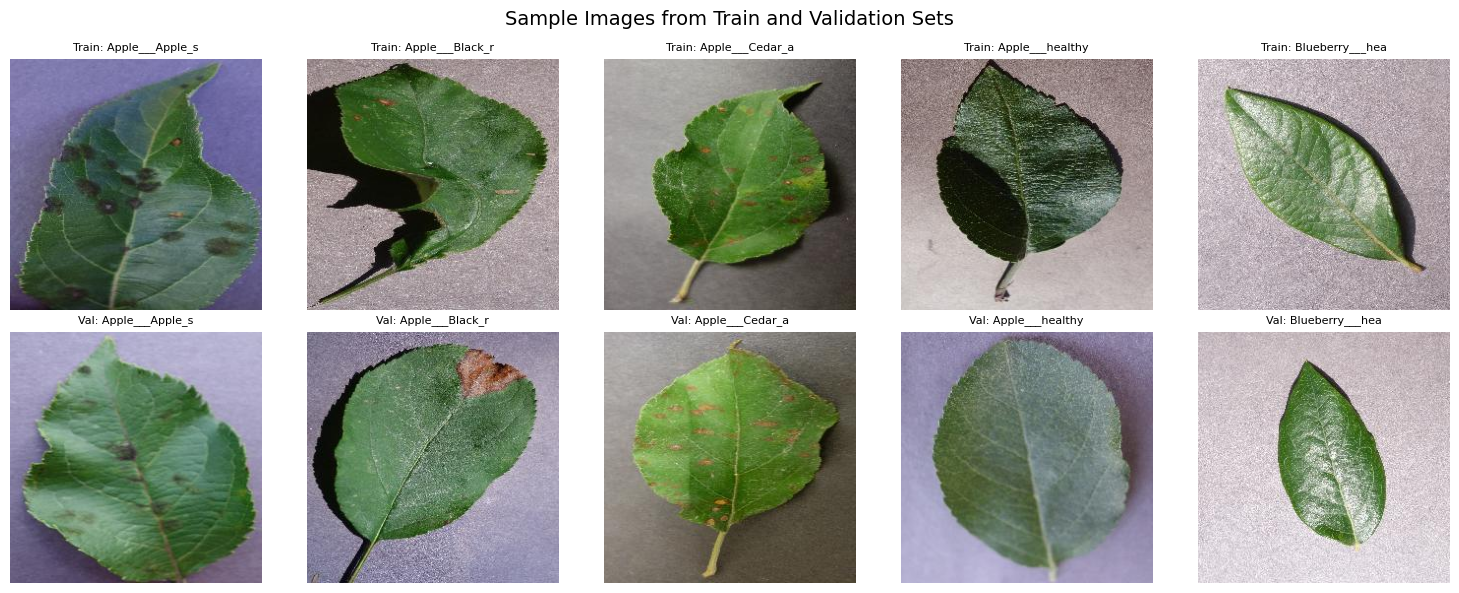

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    class_idx = train_labels.index(i) if i < len(class_names) else 0
    img = train_images[class_idx]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f'Train: {class_names[i][:15]}', fontsize=8)
    axes[0, i].axis('off')

for i in range(5):
    class_idx = val_labels.index(i) if i < len(class_names) else 0
    img = val_images[class_idx]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img_rgb)
    axes[1, i].set_title(f'Val: {class_names[i][:15]}', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Sample Images from Train and Validation Sets', fontsize=14)
plt.tight_layout()
plt.show()

### Check for grayscale or corrupt images:

In [14]:
train_grayscale = sum(1 for img in train_images if len(img.shape) == 2)
train_corrupt = sum(1 for img in train_images if len(img.shape) == 3 and img.shape[2] != 3)

val_grayscale = sum(1 for img in val_images if len(img.shape) == 2)
val_corrupt = sum(1 for img in val_images if len(img.shape) == 3 and img.shape[2] != 3)

print("DATA QUALITY CHECK:")
print(f"Train set - Grayscale: {train_grayscale}, Corrupt: {train_corrupt}")
print(f"Val set - Grayscale: {val_grayscale}, Corrupt: {val_corrupt}")
print("✓ Both datasets are clean!" if train_grayscale + train_corrupt + val_grayscale + val_corrupt == 0 else "⚠ Issues found!")

DATA QUALITY CHECK:
Train set - Grayscale: 0, Corrupt: 0
Val set - Grayscale: 0, Corrupt: 0
✓ Both datasets are clean!


- No grayscale images found
- No corrupt or unusual images detected
- Dataset is clean and consistent
- No special handling needed for image format issues

## Data Preprocessing

1. **Resize images** to 224×224 (CNN requirement)
2. **Convert BGR to RGB** (OpenCV → PyTorch format)
3. **Normalize pixel values** using ImageNet statistics
4. **Apply data augmentation** to train set only
5. **Create DataLoaders** for both train and val sets

In [15]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Define Transformation Pipelines

**Train transforms (with augmentation):**
- Resize to 224×224
- Random horizontal/vertical flips
- Random rotation (±15°)
- Color jitter (brightness/contrast)
- Convert to tensor (BGR→RGB handled automatically)
- Normalize with ImageNet statistics

**Val transforms (no augmentation):**
- Resize to 224×224
- Convert to tensor
- Normalize

In [17]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [18]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Load Datasets Using ImageFolder

`ImageFolder` automatically:
- Loads images from folder structure
- Assigns labels based on subfolder names
- Uses PIL (handles BGR→RGB conversion)
- Applies transforms on-the-fly

In [19]:
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)

print(f"rain dataset loaded from: {train_path}")
print(f"Classes: {len(train_dataset.classes)}")
print(f"Samples: {len(train_dataset)}")
print(f"Class-to-index: {train_dataset.class_to_idx}")

rain dataset loaded from: dataset/archive/PlantVillage/train
Classes: 38
Samples: 43444
Class-to-index: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healt

In [20]:
val_dataset = datasets.ImageFolder(root=val_path, transform=val_transform)

print(f"Val dataset loaded from: {val_path}")
print(f"Classes: {len(val_dataset.classes)}")
print(f"Samples: {len(val_dataset)}")
print(f"Class-to-index: {val_dataset.class_to_idx}")

Val dataset loaded from: dataset/archive/PlantVillage/val
Classes: 38
Samples: 10861
Class-to-index: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy'

In [21]:
if train_dataset.classes == val_dataset.classes:
    print("Train and val datasets have identical class structure")
    num_classes = len(train_dataset.classes)
    class_names = train_dataset.classes
else:
    print("Warning: Train and val classes differ!")
    print(f"Train classes: {train_dataset.classes}")
    print(f"Val classes: {val_dataset.classes}")

Train and val datasets have identical class structure


### Create DataLoaders

DataLoaders handle:
- Batching (32 samples per batch)
- Shuffling (train only)
- Parallel loading (num_workers=2)
- Memory efficiency

In [22]:
BATCH_SIZE = 32
NUM_WORKERS = 2  

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")
print(f"Batch size: {BATCH_SIZE}")

Train loader: 1358 batches
Val loader: 340 batches
Batch size: 32


In [23]:
from torch.nn import CrossEntropyLoss

train_labels = [label for _, label in train_dataset]
class_counts = Counter(train_labels)
total_samples = sum(class_counts.values())
class_weights = [total_samples / (len(class_counts) * class_counts[i]) for i in range(len(class_counts))]
class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class weights:", class_weights)

criterion = CrossEntropyLoss(weight=class_weights.to(device))

Class weights: tensor([2.2684, 2.3050, 5.1967, 0.8687, 0.9511, 1.3578, 1.6714, 2.7884, 1.1996,
        1.4508, 1.2306, 1.2111, 1.0328, 1.3278, 3.3725, 0.2595, 0.6220, 3.9697,
        1.4345, 0.9664, 1.4291, 1.4291, 9.4485, 3.8494, 0.2808, 0.7788, 1.2889,
        3.1408, 0.6717, 1.4291, 0.7487, 1.5023, 0.8068, 0.8525, 1.0180, 0.2667,
        3.8236, 0.8981])


### Verify Preprocessing Pipeline

Check batch shapes and data flow

In [24]:
train_batch_images, train_batch_labels = next(iter(train_loader))
val_batch_images, val_batch_labels = next(iter(val_loader))

print("TRAIN BATCH:")
print(f"  Images shape: {train_batch_images.shape}")  
print(f"  Labels shape: {train_batch_labels.shape}")  
print(f"  Images dtype: {train_batch_images.dtype}")
print(f"  Value range: [{train_batch_images.min():.3f}, {train_batch_images.max():.3f}]")

print("\nVAL BATCH:")
print(f"  Images shape: {val_batch_images.shape}")
print(f"  Labels shape: {val_batch_labels.shape}")
print(f"  Images dtype: {val_batch_images.dtype}")
print(f"  Value range: [{val_batch_images.min():.3f}, {val_batch_images.max():.3f}]")

print("\nPipeline working correctly!" if train_batch_images.shape[0] == BATCH_SIZE else "Batch size issue!")

TRAIN BATCH:
  Images shape: torch.Size([32, 3, 224, 224])
  Labels shape: torch.Size([32])
  Images dtype: torch.float32
  Value range: [-2.118, 2.640]

VAL BATCH:
  Images shape: torch.Size([32, 3, 224, 224])
  Labels shape: torch.Size([32])
  Images dtype: torch.float32
  Value range: [-2.101, 2.640]

Pipeline working correctly!


### Visualize Data Augmentation Effects

Compare original vs augmented images

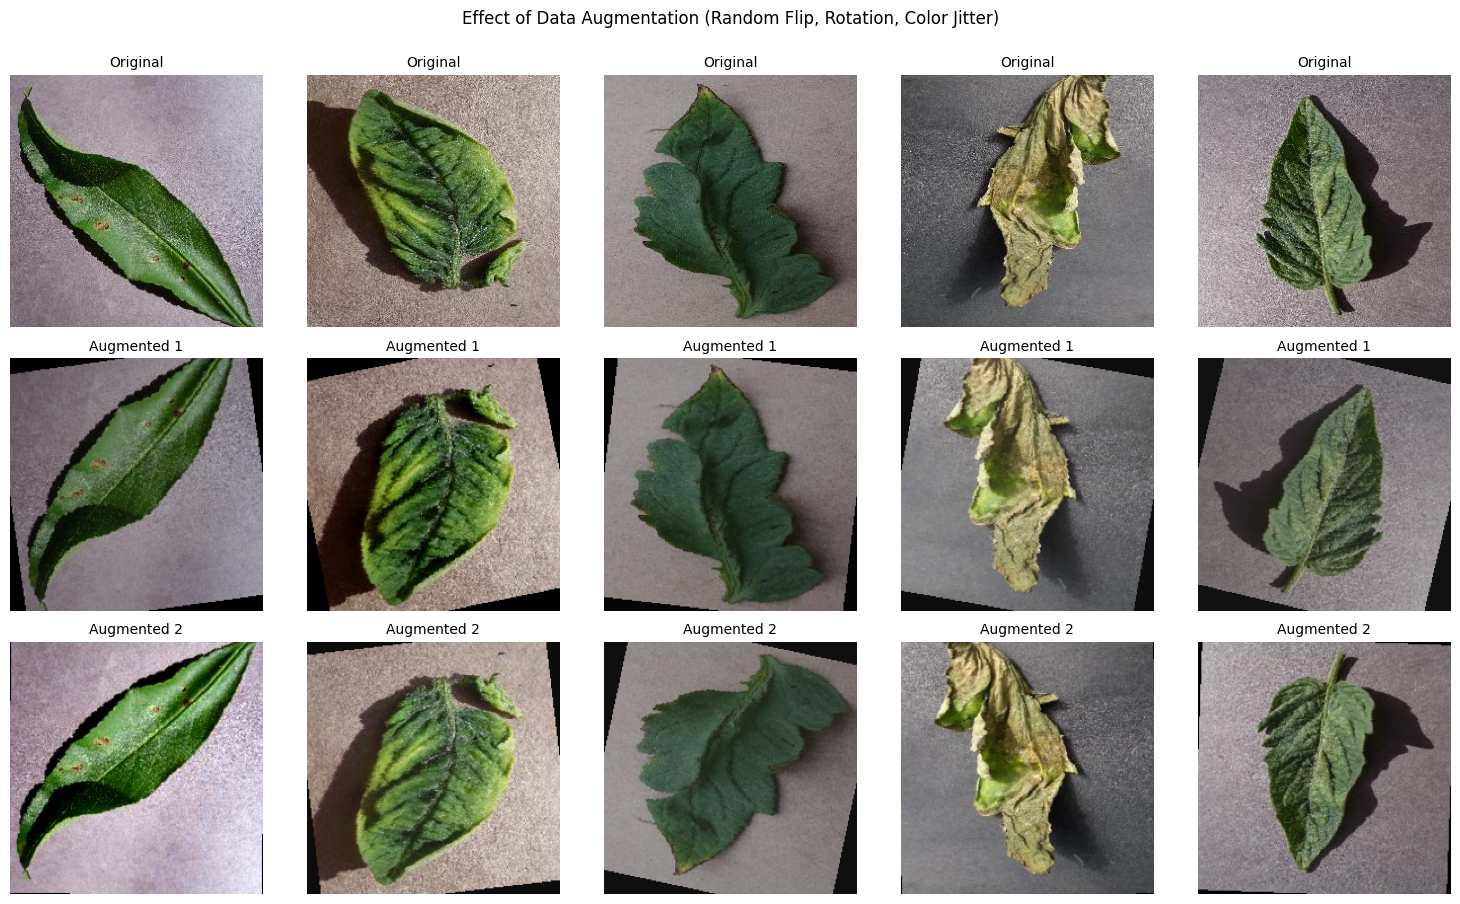

In [25]:
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Reverse normalization for visualization"""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

np.random.seed(42)
sample_indices = np.random.choice(len(train_image_paths), 5, replace=False)

for col, idx in enumerate(sample_indices):
    img_path = train_image_paths[idx]
    original_img = Image.open(img_path)
    
    axes[0, col].imshow(original_img)
    axes[0, col].set_title('Original', fontsize=10)
    axes[0, col].axis('off')
    
    aug1 = train_transform(original_img)
    aug1_display = denormalize(aug1.clone()).permute(1, 2, 0).numpy()
    axes[1, col].imshow(aug1_display)
    axes[1, col].set_title('Augmented 1', fontsize=10)
    axes[1, col].axis('off')
    
    aug2 = train_transform(original_img)
    aug2_display = denormalize(aug2.clone()).permute(1, 2, 0).numpy()
    axes[2, col].imshow(aug2_display)
    axes[2, col].set_title('Augmented 2', fontsize=10)
    axes[2, col].axis('off')

plt.suptitle('Effect of Data Augmentation (Random Flip, Rotation, Color Jitter)', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

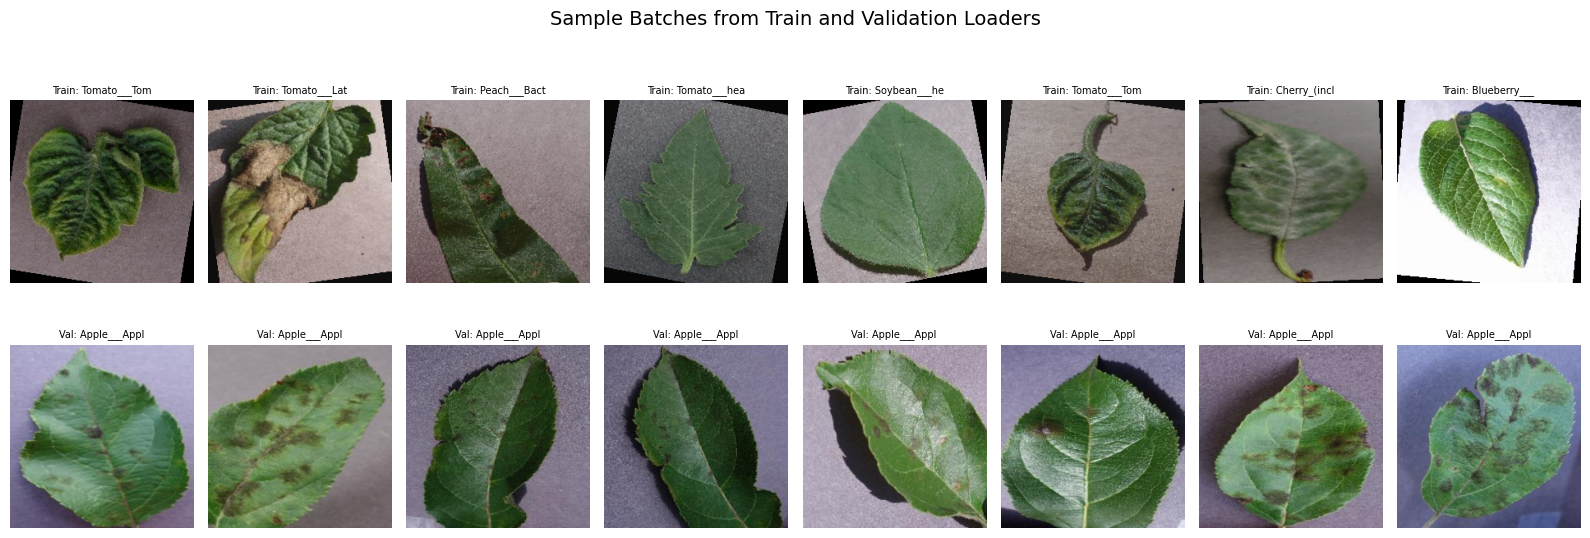

In [26]:
fig, axes = plt.subplots(2, 8, figsize=(16, 6))

train_images, train_labels_batch = next(iter(train_loader))
for i in range(8):
    img = denormalize(train_images[i].clone()).permute(1, 2, 0).numpy()
    label_idx = train_labels_batch[i].item()
    label_name = class_names[label_idx]
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Train: {label_name[:12]}', fontsize=7)
    axes[0, i].axis('off')

val_images, val_labels_batch = next(iter(val_loader))
for i in range(8):
    img = denormalize(val_images[i].clone()).permute(1, 2, 0).numpy()
    label_idx = val_labels_batch[i].item()
    label_name = class_names[label_idx]
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Val: {label_name[:12]}', fontsize=7)
    axes[1, i].axis('off')

plt.suptitle('Sample Batches from Train and Validation Loaders', fontsize=14)
plt.tight_layout()
plt.show()

### Model Training

1. MLP
2. CNN

In [27]:
import torch.optim as optim
from tqdm import tqdm
import torch.nn as nn
from torchsummary import summary


### MLP

In [28]:
class SampleNN(nn.Module):
    def __init__(self, input_size, hidden_units, num_classes):
        super(SampleNN, self).__init__()
        
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)

input_size = 224 * 224 * 3
hidden_units = 128
num_classes = len(class_names)

model = SampleNN(input_size=input_size, hidden_units=hidden_units, num_classes=num_classes)
model.to(device)
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1               [-1, 150528]               0
            Linear-2                  [-1, 128]      19,267,712
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 38]           4,902
Total params: 19,272,614
Trainable params: 19,272,614
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 1.15
Params size (MB): 73.52
Estimated Total Size (MB): 75.24
----------------------------------------------------------------


In [29]:
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)  

In [30]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [31]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [32]:
num_epochs = 5

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    scheduler.step()

print("Training complete!")

Epoch 1/5


Validating: 100%|██████████| 340/340 [00:11<00:00, 29.26it/s]


Train Loss: 5.0464, Train Acc: 0.0861
Val Loss: 5.4884, Val Acc: 0.1885
Epoch 2/5


Validating: 100%|██████████| 340/340 [00:10<00:00, 31.46it/s]


Train Loss: 3.7699, Train Acc: 0.1629
Val Loss: 6.2108, Val Acc: 0.1431
Epoch 3/5


...

Train Loss: 3.7419, Train Acc: 0.1290
Val Loss: 6.1703, Val Acc: 0.1143
Epoch 4/5


Validating: 100%|██████████| 340/340 [00:12<00:00, 28.27it/s]


Train Loss: 3.8724, Train Acc: 0.1377
Val Loss: 8.6534, Val Acc: 0.1525
Epoch 5/5


Validating: 100%|██████████| 340/340 [00:14<00:00, 23.31it/s]

Train Loss: 3.7056, Train Acc: 0.1123
Val Loss: 8.5348, Val Acc: 0.1241
Training complete!


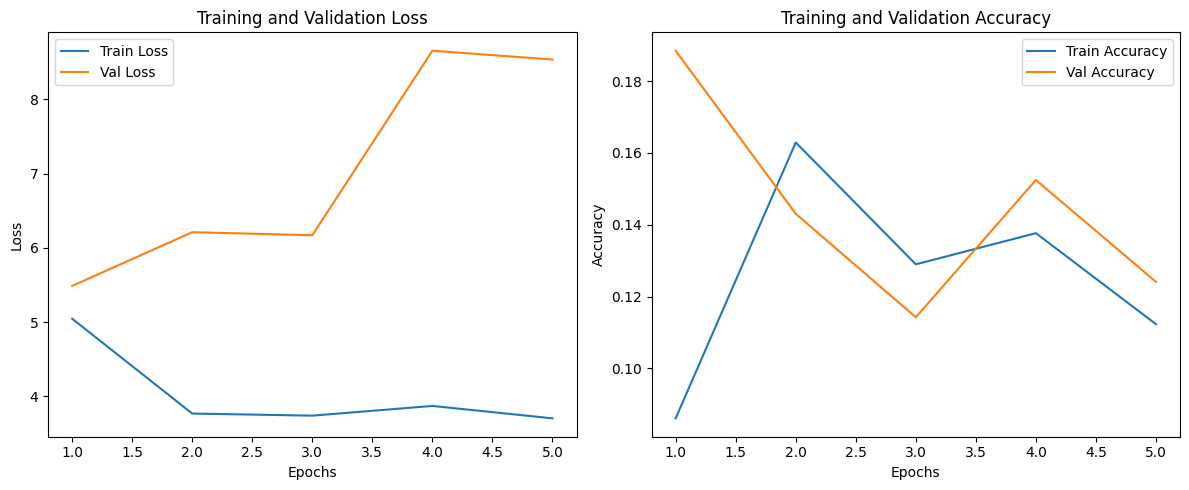

In [33]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [34]:
import random

def test_model_on_samples(model, dataset, class_names, num_samples=2, device='cuda'):

    model.eval()
    
    # Randomly select samples
    sample_indices = random.sample(range(len(dataset)), num_samples)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(5*num_samples, 5))
    if num_samples == 1:
        axes = [axes]
    
    with torch.no_grad():
        for idx, sample_idx in enumerate(sample_indices):
            # Get image and true label
            image, true_label = dataset[sample_idx]
            true_class_name = class_names[true_label]
            
            # Prepare image for model (add batch dimension)
            image_batch = image.unsqueeze(0).to(device)
            
            # Get prediction
            output = model(image_batch)
            probabilities = torch.softmax(output, dim=1)
            pred_prob, pred_label = torch.max(probabilities, 1)
            pred_class_name = class_names[pred_label.item()]
            
            # Denormalize image for display
            img_display = denormalize(image.clone()).permute(1, 2, 0).cpu().numpy()
            
            # Display
            axes[idx].imshow(img_display)
            axes[idx].axis('off')
            
            # Color code: Green if correct, Red if wrong
            color = 'green' if pred_label.item() == true_label else 'red'
            title = f"True: {true_class_name}\n"
            title += f"Pred: {pred_class_name}\n"
            title += f"Confidence: {pred_prob.item()*100:.1f}%"
            axes[idx].set_title(title, fontsize=10, color=color, weight='bold')
    
    plt.tight_layout()
    plt.show()

print("✓ Prediction function defined")

✓ Prediction function defined


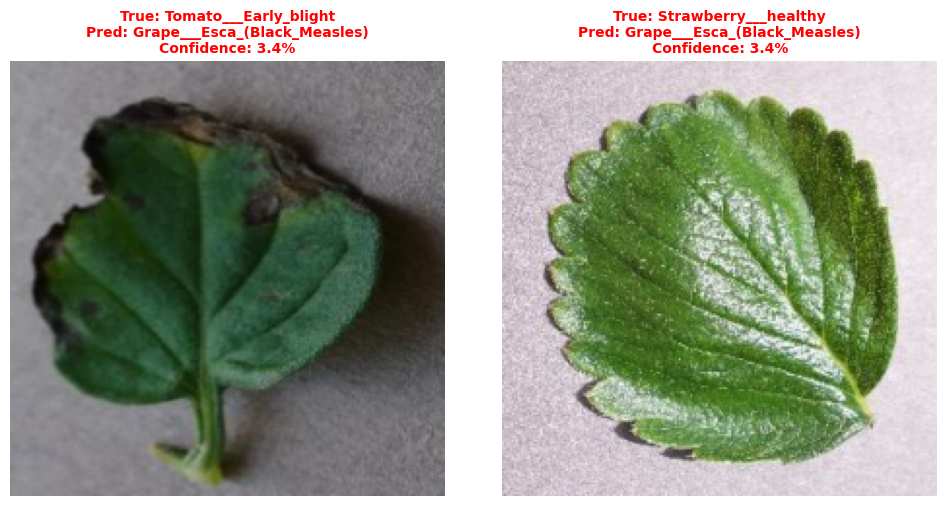

In [35]:
test_model_on_samples(
    model=model, 
    dataset=val_dataset,
    class_names=class_names,
    num_samples=2,
    device=device
)

In [36]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=len(class_names))
model.to(device)
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 224]               0
         MaxPool2d-4         [-1, 32, 112, 112]               0
            Conv2d-5         [-1, 64, 112, 112]          18,496
       BatchNorm2d-6         [-1, 64, 112, 112]             128
              ReLU-7         [-1, 64, 112, 112]               0
         MaxPool2d-8           [-1, 64, 56, 56]               0
            Conv2d-9          [-1, 128, 56, 56]          73,856
      BatchNorm2d-10          [-1, 128, 56, 56]             256
             ReLU-11          [-1, 128, 56, 56]               0
        MaxPool2d-12          [-1, 128, 28, 28]               0
          Flatten-13               [-1, 100352]               0
           Linear-14                  [

In [37]:
learning_rate = 0.0001
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f"Optimizer: Adam(lr={learning_rate}, weight_decay=1e-4)")
print(f"Scheduler: ReduceLROnPlateau (reduces LR when validation loss plateaus)")

Optimizer: Adam(lr=0.0001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (reduces LR when validation loss plateaus)


In [38]:
num_epochs = 5

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 70)
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc*100:.2f}%")
    
    # Step scheduler with validation loss
    scheduler.step(val_loss)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_simplecnn_model.pth')
        print(f"✓ Best model saved! Val Acc: {val_acc*100:.2f}%")

print("\n" + "=" * 70)
print(f"Training complete! Best Val Accuracy: {best_val_acc*100:.2f}%")


Epoch 1/5
----------------------------------------------------------------------


Validating: 100%|██████████| 340/340 [00:16<00:00, 20.07it/s]


Train Loss: 3.3218, Train Acc: 13.49%
Val Loss:   2.3923, Val Acc:   42.93%
✓ Best model saved! Val Acc: 42.93%

Epoch 2/5
----------------------------------------------------------------------


Validating: 100%|██████████| 340/340 [00:19<00:00, 17.36it/s]


Train Loss: 2.8582, Train Acc: 20.98%
Val Loss:   1.8172, Val Acc:   56.40%
✓ Best model saved! Val Acc: 56.40%

Epoch 3/5
----------------------------------------------------------------------


...

Train Loss: 2.5680, Train Acc: 25.15%
Val Loss:   1.7595, Val Acc:   56.84%
✓ Best model saved! Val Acc: 56.84%

Epoch 4/5
----------------------------------------------------------------------


Validating: 100%|██████████| 340/340 [00:19<00:00, 17.83it/s]


Train Loss: 2.4416, Train Acc: 26.98%
Val Loss:   1.5121, Val Acc:   63.35%
✓ Best model saved! Val Acc: 63.35%

Epoch 5/5
----------------------------------------------------------------------


Validating: 100%|██████████| 340/340 [00:19<00:00, 17.74it/s]


Train Loss: 2.3401, Train Acc: 28.71%
Val Loss:   1.3788, Val Acc:   66.84%
✓ Best model saved! Val Acc: 66.84%

Training complete! Best Val Accuracy: 66.84%


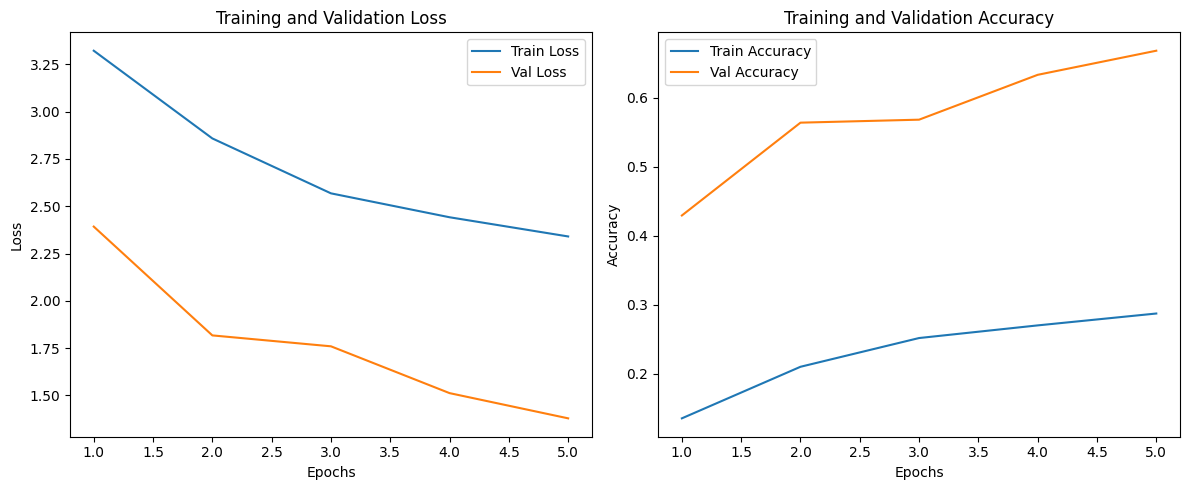

In [39]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

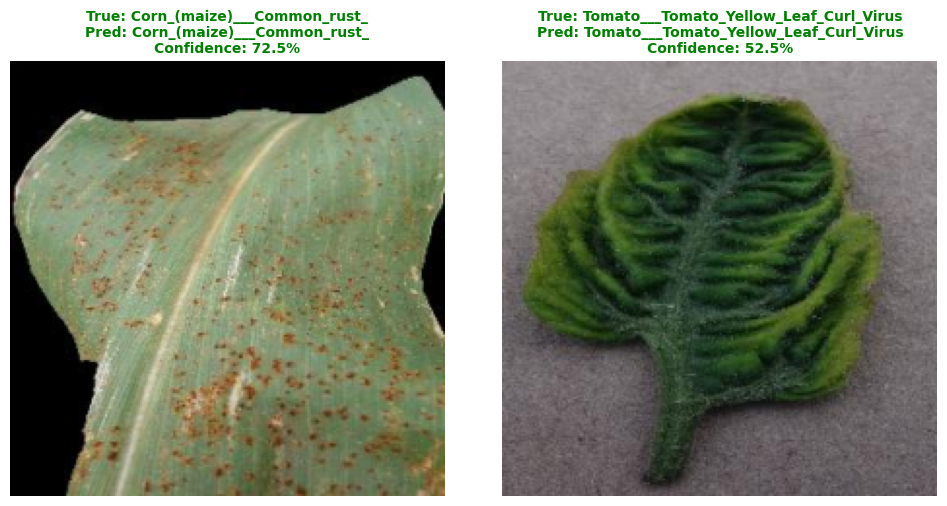

In [40]:
test_model_on_samples(
    model=model,
    dataset=val_dataset,
    class_names=class_names,
    num_samples=2,
    device=device
)

Model Save

In [43]:
model_save_path = 'best_simplecnn_plant_disease.pth'

torch.save({
    'model_state_dict': model.state_dict(),  
    'class_names': class_names,
    'num_classes': len(class_names),
    'input_size': (3, 224, 224)
}, model_save_path)